In [29]:
import cv2
import numpy as np
from scipy.stats import skew
from matplotlib import pyplot as plt
from pathlib import Path
import cv2
from sklearn.discriminant_analysis import StandardScaler


def metricas(imagen):

    datos = imagen.flatten().astype(np.float64)

    media = np.mean(datos)
    std = np.std(datos)

    # Energía
    energia = np.mean(datos**2)

    # Asimetría robusta
    if std < 1e-8:
        asimetria = 0.0
    else:
        momento3 = np.mean((datos - media)**3)
        asimetria = momento3 / (std**3)

    return std, asimetria, energia

kernel_sobel_v = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

kernel_sobel_h = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
], dtype=np.float32)

kernel_laplaciano = np.array([
    [ 0, -1,  0],
    [-1,  4, -1],
    [ 0, -1,  0]
], dtype=np.float32)


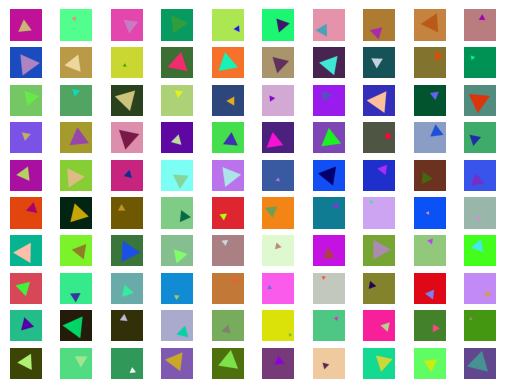

In [30]:
base_datos_imagen_C = []

for i in range(1,101):
    carpeta = Path("Base_datos") / "T"
    ruta = carpeta / f"T ({i}).png"   
    imagen = cv2.imread(ruta)
    
    base_datos_imagen_C.append(imagen)
    
    plt.subplot(10, 10, i)
    plt.imshow(imagen)
    plt.axis("off")

plt.show()  

In [31]:



sf = np.zeros(59)
af = np.zeros(59)   
ef = np.zeros(59)   

for i in range(1,60):
      
    imagen = base_datos_imagen_C[i-1]    # Tomar la i-ésima imagen de la base de datos
    #print("Dimensiones de la imagen:", imagen.shape)

    # Convertir la imagen a escala de grises
    gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY) 
    #print("Dimensiones de la imagen:", gris.shape)

    # filtro de  Sobel vertical
    sobel_v = cv2.filter2D(gris, cv2.CV_64F, kernel_sobel_v)
    # filtro de  Sobel horizontal
    sobel_h = cv2.filter2D(gris, cv2.CV_64F, kernel_sobel_h)
    # filtro de Laplaciano      
    laplaciano = cv2.filter2D(gris, cv2.CV_64F, kernel_laplaciano)

    #print("Dimensiones de la imagen:", sobel_v.shape)
    #print("Dimensiones de la imagen:", sobel_h.shape)
    #print("Dimensiones de la imagen:", laplaciano.shape)

    # Calcular las características estadísticas

    s1, a1, e1 = metricas(sobel_v)
    s2, a2, e2 = metricas(sobel_h)
    s3, a3, e3 = metricas(laplaciano)
    
    #print("Sobel Vertical - Desviación Estándar:", s1 , "Asimetría:", a1, "Energía:", e1)
    #print("Sobel Horizontal - Desviación Estándar:", s2, "Asimetría:", a2, "Energía:", e2)
    #print("Laplaciano - Desviación Estándar:", s3, "Asimetría:", a3, "Energía:", e3)

    s = (s1 + s2 + s3) / 3
    a = (a1 + a2 + a3) / 3
    e = (e1 + e2 + e3) / 3  
    
    sf[i-1] = s
    af[i-1] = a 
    ef[i-1] = e

print("Vector de desviación estándar (sf):", sf.shape)
print("Vector de asimetría (af):", af.shape)        
print("Vector de energía (ef):", ef.shape)

m1 = np.mean(sf)
m2 = np.mean(af)
m3 = np.mean(ef)  

print("Media de sf:", m1)
print("Media de af:", m2)       
print("Media de ef:", m3)

X_total = np.vstack((m1, m2, m3))

scaler = StandardScaler()
X_total = scaler.fit_transform(X_total) 

print("Matriz de características normalizada (X_total):", X_total.shape) 
print("Matriz de características normalizada (X_total):", X_total)


Vector de desviación estándar (sf): (59,)
Vector de asimetría (af): (59,)
Vector de energía (ef): (59,)
Media de sf: 14.157656582996932
Media de af: 0.15402626015844847
Media de ef: 348.0837138418079
Matriz de características normalizada (X_total): (3, 1)
Matriz de características normalizada (X_total): [[-0.66312069]
 [-0.75019896]
 [ 1.41331966]]
